In [1]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Aarav@2207",
    database="retail_store_ml"
)

query = """
SELECT
    `Customer ID`,
    COUNT(DISTINCT Invoice) AS Frequency,
    SUM(Quantity) AS TotalQuantity,
    AVG(Price) AS AvgPrice,
    COUNT(DISTINCT StockCode) AS ProductCount,
    SUM(Quantity * Price) AS TotalSpend
FROM retail
WHERE `Customer ID` IS NOT NULL
  AND Quantity > 0
  AND Price > 0
GROUP BY `Customer ID`;
"""

df = pd.read_sql(query, conn)

conn.close()

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_136652\592228370.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Customer ID,Frequency,TotalQuantity,AvgPrice,ProductCount,TotalSpend
0,0,1428,841128.0,6.288362,3301,3.510553e+06
1,12346,1,148430.0,1.040000,1,1.543672e+05
2,12347,7,4916.0,2.644011,103,8.620000e+03
3,12348,4,4682.0,5.764839,22,3.594480e+03
4,12349,1,1262.0,8.289041,73,3.515100e+03


In [2]:
query = """
Select `Customer ID`,
    Invoice , 
    Quantity,
    Price,
    `InvoiceDate`,
    StockCode
FROM retail
WHERE `Customer ID` IS NOT NULL
  AND Quantity > 0
  AND Price > 0;
"""

if not conn.is_connected():
    conn.reconnect(attempts=3, delay=2)

transactions = pd.read_sql(query, conn)

transactions['InvoiceDate'] = pd.to_datetime(transactions['InvoiceDate'])

transactions.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_136652\636480706.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions = pd.read_sql(query, conn)


,Customer ID,Invoice,Quantity,Price,InvoiceDate,StockCode
0,17850,536365,6,2.55,2010-12-01 08:26:00,85123A
1,17850,536365,6,3.39,2010-12-01 08:26:00,71053
2,17850,536365,8,2.75,2010-12-01 08:26:00,84406B
3,17850,536365,6,3.39,2010-12-01 08:26:00,84029G
4,17850,536365,6,3.39,2010-12-01 08:26:00,84029E


In [3]:
print(transactions.shape)
transactions['InvoiceDate'].min() , transactions['InvoiceDate'].max()

(1060210, 6)


(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [3]:
cutoff_date = pd.Timestamp('2011-09-01')
future_end = cutoff_date + pd.Timedelta(days = 90)

print(cutoff_date)
print(future_end)

2011-09-01 00:00:00
2011-11-30 00:00:00


In [4]:
historical = transactions[transactions['InvoiceDate']<cutoff_date].copy()

cutomer_features = historical.groupby('Customer ID').agg(
    LastPurchaseDate = ('InvoiceDate' , 'max'),
    FirstPurchaseDate = ('InvoiceDate' , 'min'),
    Frequency = ('Invoice' ,'nunique'),
    Monetary = ('Price' ,lambda x: (x * historical.loc[x.index, 'Quantity']).sum()),
    UniqueProducts = ('StockCode' , 'nunique')
).reset_index()

customer_features = cutomer_features.copy()

customer_features['Recency'] = (cutoff_date - customer_features['LastPurchaseDate']).dt.days
customer_features['CustomerLifetimeDays'] = (customer_features['LastPurchaseDate'] - customer_features['FirstPurchaseDate']).dt.days + 1
customer_features['AverageOrderValue'] = (customer_features['Monetary'] - customer_features['Frequency'])
customer_features['PurchaseRate'] = (customer_features['Frequency'] - customer_features['CustomerLifetimeDays'])
customer_features = customer_features[customer_features['Customer ID'] > 0].copy()

customer_features.head()


,Customer ID,LastPurchaseDate,FirstPurchaseDate,Frequency,Monetary,UniqueProducts,Recency,CustomerLifetimeDays,AverageOrderValue,PurchaseRate
1,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,154367.20,1,225,1,154366.20,0
2,12347,2011-08-02 08:48:00,2010-12-07 14:57:00,5,5581.72,82,29,238,5576.72,-233
3,12348,2011-04-05 10:47:00,2010-12-16 19:09:00,3,2974.48,22,148,110,2971.48,-107
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,668.80,17,210,1,667.80,0
5,12352,2011-03-22 16:08:00,2011-02-16 12:33:00,5,3123.62,26,162,35,3118.62,-30


In [6]:
print("Customers:", len(customer_features))
print("Minimum Customer ID:", customer_features['Customer ID'].min())
print("Maximum Customer ID:", customer_features['Customer ID'].max())

Customers: 3317
Minimum Customer ID: 12346
Maximum Customer ID: 18287


In [5]:
future = transactions[(transactions['InvoiceDate']>=cutoff_date)&(transactions['InvoiceDate']<future_end).copy()]
future['Spend'] = future['Price'] * future['Quantity']

future_spend = (future.groupby('Customer ID')['Spend'].sum().reset_index().rename(columns= {'Spend': 'Future90DaySpend'}))

regression_data = customer_features.merge(future_spend,on='Customer ID',how='left')
regression_data['Future90DaySpend'] = (regression_data['Future90DaySpend'].fillna(0))

regression_data.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_136652\3937192198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future['Spend'] = future['Price'] * future['Quantity']


,Customer ID,LastPurchaseDate,FirstPurchaseDate,Frequency,Monetary,UniqueProducts,Recency,CustomerLifetimeDays,AverageOrderValue,PurchaseRate,Future90DaySpend
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,154367.20,1,225,1,154366.20,0,0.00
1,12347,2011-08-02 08:48:00,2010-12-07 14:57:00,5,5581.72,82,29,238,5576.72,-233,2588.64
2,12348,2011-04-05 10:47:00,2010-12-16 19:09:00,3,2974.48,22,148,110,2971.48,-107,620.00
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,668.80,17,210,1,667.80,0,0.00
4,12352,2011-03-22 16:08:00,2011-02-16 12:33:00,5,3123.62,26,162,35,3118.62,-30,1888.46


In [20]:
print("Dataset shape:", regression_data.shape)
print(regression_data['Future90DaySpend'].describe())
print(
    "Customers with future spend:",
    (regression_data['Future90DaySpend'] > 0).sum()
)
print(
    "Customers with zero future spend:",
    (regression_data['Future90DaySpend'] == 0).sum()
)

Dataset shape: (3317, 11)
count      3317.000000
mean       1537.339120
std        7838.658514
min           0.000000
25%           0.000000
50%         336.160000
75%        1352.580000
max      235269.060000
Name: Future90DaySpend, dtype: float64
Customers with future spend: 1864
Customers with zero future spend: 1453


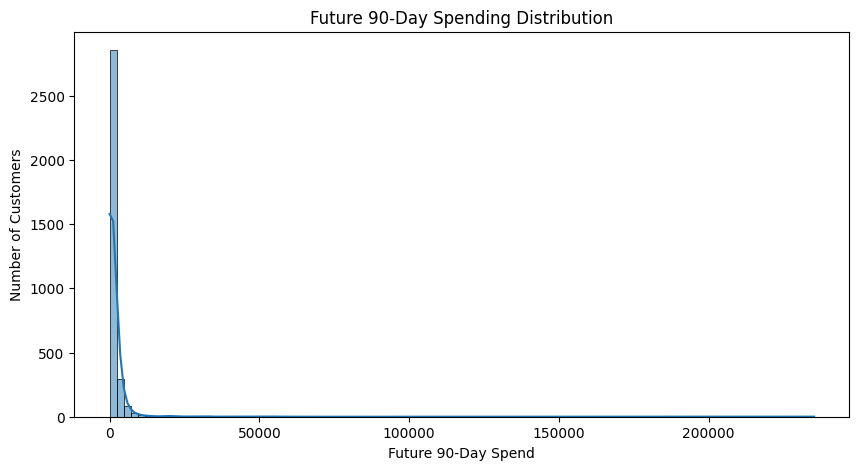

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(regression_data['Future90DaySpend'], bins=100, kde=True)

plt.title('Future 90-Day Spending Distribution')
plt.xlabel('Future 90-Day Spend')
plt.ylabel('Number of Customers')
plt.show()

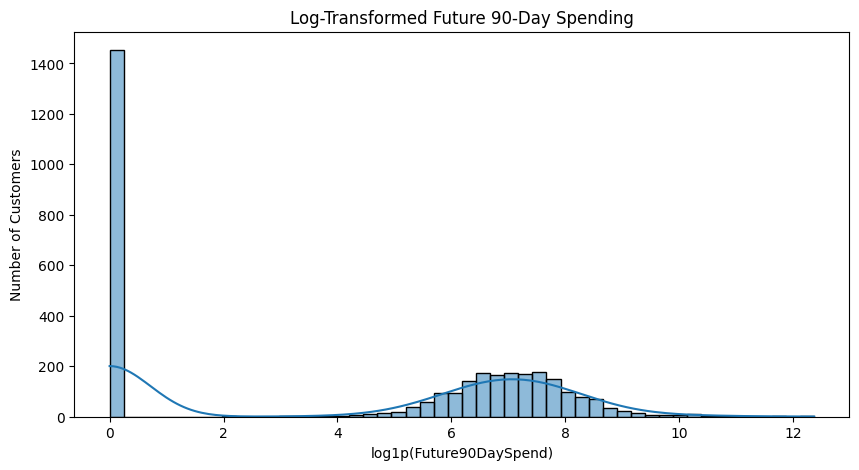

In [ ]:
import numpy as np

plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(regression_data['Future90DaySpend']), bins=50, kde=True)

plt.title('Log-Transformed Future 90-Day Spending')
plt.xlabel('log1p(Future90DaySpend)')
plt.ylabel('Number of Customers')
plt.show()

In [7]:
import sklearn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df.shape

(4339, 6)

In [5]:
df.describe()

,Customer ID,Frequency,TotalQuantity,AvgPrice,ProductCount,TotalSpend
count,4339.00000,4339.000000,4339.000000,4339.000000,4339.000000,4.339000e+03
mean,15296.88177,4.600138,2575.882461,4.468255,62.247753,4.916664e+03
std,1737.20873,22.943499,16246.876555,34.207517,98.510994,5.618530e+04
min,0.00000,1.000000,2.000000,0.122500,1.000000,7.500000e+00
25%,13812.50000,1.000000,320.000000,2.203790,16.000000,6.148600e+02
50%,15299.00000,2.000000,758.000000,2.917778,35.000000,1.349040e+03
75%,16778.50000,5.000000,1986.000000,3.832075,77.000000,3.324120e+03
max,18287.00000,1428.000000,841128.000000,2033.100000,3301.000000,3.510553e+06


In [6]:
X = df[['Frequency','TotalQuantity','AvgPrice',	'ProductCount']]
Y = df['TotalSpend']

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[1711.22, 1.42, 8.11, -78.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Frequency','TotalQuantity','AvgPrice','ProductCount']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1790
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [12]:
Y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [14]:
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6197329157049565
MSE is : 158641291.54551387
RMSE is : 12595.288466149312
MAE is : 4577.694653749538


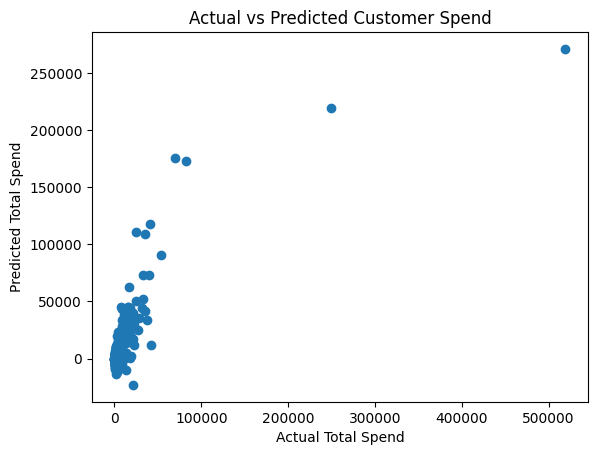

In [15]:
plt.scatter(Y_test, Y_pred)

plt.xlabel("Actual Total Spend")
plt.ylabel("Predicted Total Spend")
plt.title("Actual vs Predicted Customer Spend")

plt.show()

In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

         Feature  Coefficient
0      Frequency  1711.217125
1  TotalQuantity     1.418351
2       AvgPrice     8.111041
3   ProductCount   -78.058480


In [17]:
model.intercept_

np.float64(-1789.718748704573)

In [18]:
from sklearn.linear_model import Ridge

In [19]:
model = Ridge(alpha = 1)

In [20]:
model.fit(X_train , Y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [21]:
Y_pred = model.predict(X_test)

In [22]:
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6197336112177803
MSE is : 158641001.3887867
RMSE is : 12595.276947681092
MAE is : 4577.6892578872885


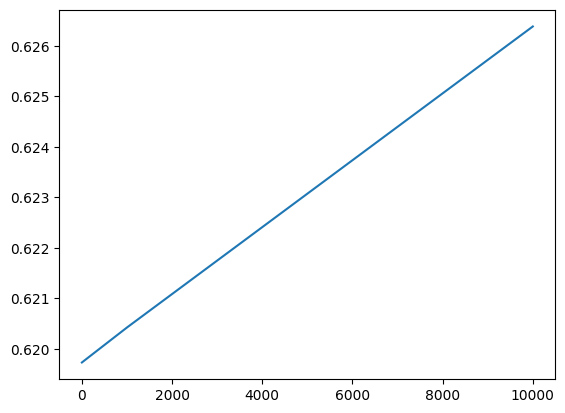

In [23]:
alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000]
r2_scores = []

for alpha in alphas:
    model = Ridge(alpha = alpha)
    model.fit(X_train,Y_train)
    Y_pred = model.predict(X_test)
    score = r2_score(Y_test , Y_pred)
    r2_scores.append(score)

plt.plot(alphas, r2_scores)
plt.show()

In [24]:
from sklearn.linear_model import Lasso

In [25]:
model = Lasso(alpha = 1)

In [26]:
model.fit(X_train,Y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [27]:
Y_pred = model.predict(X_test)

In [28]:
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6197343035079045
MSE is : 158640712.5765177
RMSE is : 12595.265482573906
MAE is : 4577.682640842578


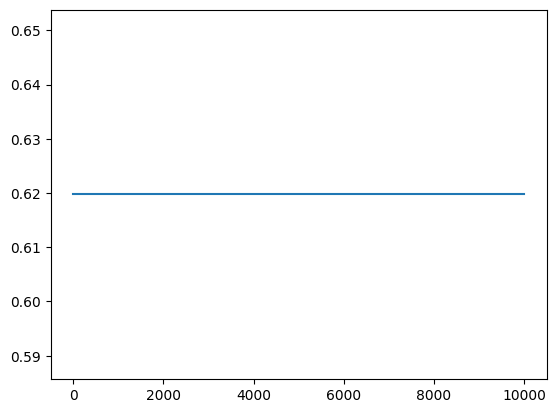

In [29]:
alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000]
r2_scores = []

for alpha in alphas:
    model = Lasso(alpha = alpha)
    model.fit(X_train, Y_train)
    model.predict(X_test)
    score = r2_score(Y_test, Y_pred)
    r2_scores.append(score)

plt.plot(alphas , r2_scores)
plt.show()

In [30]:
best_index = r2_scores.index(max(r2_scores))
best_alpha = alphas[best_index]
model = Lasso(alpha=best_alpha, max_iter=10000)

model.fit(X_train, Y_train)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

         Feature  Coefficient
0      Frequency  1711.217050
1  TotalQuantity     1.418351
2       AvgPrice     8.111035
3   ProductCount   -78.058474


In [31]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha = 1, l1_ratio = 0.5, max_iter = 10000)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6197343035079045
MSE is : 158640712.5765177
RMSE is : 12595.265482573906
MAE is : 4577.682640842578


In [32]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state = 42)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6197343035079045
MSE is : 158640712.5765177
RMSE is : 12595.265482573906
MAE is : 4577.682640842578


In [67]:
importance = pd.DataFrame({"features": X.columns, "importance": model.feature_importances_})
importance = importance.sort_values(by = "importance", ascending=False)
print(importance)


        features  importance
1  TotalQuantity    0.483605
3   ProductCount    0.407330
0      Frequency    0.091863
2       AvgPrice    0.017203


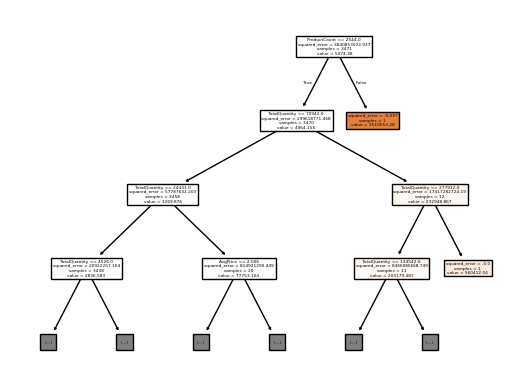

In [41]:
from sklearn.tree import plot_tree
plot_tree(model , feature_names = X.columns, max_depth = 3,filled=True )
plt.show()

In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

grid = GridSearchCV(DecisionTreeRegressor(random_state = 42), params, scoring = "r2", cv = 5, n_jobs=-1)
grid.fit(X_train, Y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contr

In [46]:
grid.best_params_

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [47]:
grid.best_score_

np.float64(0.6821331794251424)

In [60]:
best_model = grid.best_estimator_
best_model.fit(X_train, Y_train)
Y_pred = best_model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")


r2_score is : 0.6105128341471644
MSE is : 162487760.7953957
RMSE is : 12747.068713841458
MAE is : 1430.8923271889385


In [59]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators = 200, random_state = 42, n_jobs = -1)

model.fit(X_train , Y_train)
y_pred = model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6105128341471644
MSE is : 162487760.7953957
RMSE is : 12747.068713841458
MAE is : 1430.8923271889385


In [68]:
importance = pd.DataFrame({"features": X.columns, "Importance": model.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False).reset_index(drop=True)
print(importance)


        features  Importance
0  TotalQuantity    0.483605
1   ProductCount    0.407330
2      Frequency    0.091863
3       AvgPrice    0.017203


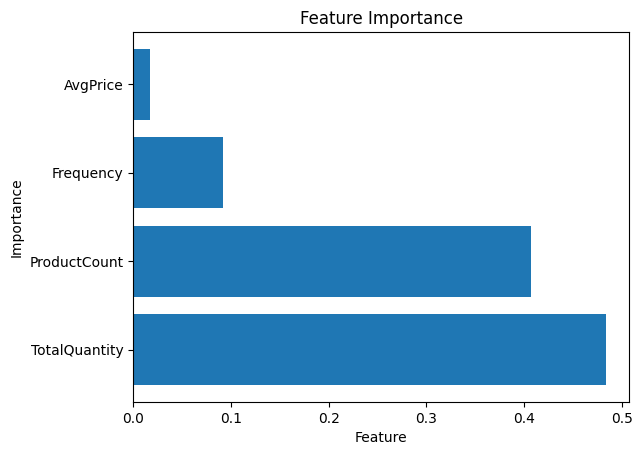

In [71]:
plt.barh(importance['features'], importance['Importance'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {"n_estimators": [1,5,10,15,20,50,100,150,200]}

grid = GridSearchCV(RandomForestRegressor(random_state = 42), params, scoring="r2", cv=5, n_jobs=-1)
grid.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_estimators': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with 

In [ ]:

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6827730006366082
MSE is : 132341985.3322612
RMSE is : 11503.998667083599
MAE is : 1156.6225614055286


In [75]:
best_model = grid.best_estimator_
best_model.predict(X_test)
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")


r2_score is : 0.6827730006366082
MSE is : 132341985.3322612
RMSE is : 11503.998667083599
MAE is : 1156.6225614055286


In [76]:
grid.best_score_

np.float64(0.7421446610102553)

In [77]:
grid.best_params_

{'n_estimators': 20}

In [81]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, random_state = 42, max_depth= 3)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")


r2_score is : 0.7731405789741281
MSE is : 94642089.8288643
RMSE is : 9728.416614684236
MAE is : 1138.4708410397757


In [82]:
importance = pd.DataFrame({'Features': X.columns, 'Importance':model.feature_importances_})
importance = importance.sort_values(by = "Importance", ascending = False)
print(importance)

        Features  Importance
1  TotalQuantity    0.475478
3   ProductCount    0.315041
0      Frequency    0.206688
2       AvgPrice    0.002793


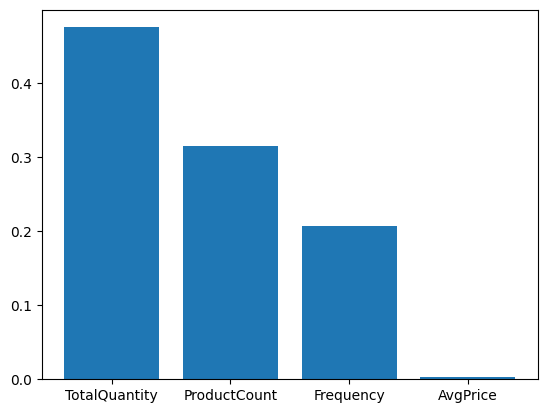

In [86]:
plt.bar(importance['Features'] , importance['Importance'])
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {"n_estimators":[1,5,10,15,20,50,100,150,200] , 'learning_rate':[0.01, 0.05, 0.1], 'max_depth': [2,3,5], 'min_samples_split':[2,5,10]}

grid = GridSearchCV(GradientBoostingRegressor(random_state = 42), params, scoring='r2', cv=5, n_jobs=-1)
grid.fit(X_train, Y_train)


In [90]:
best_model = grid.best_estimator_
best_model.fit(X_train, Y_train)
Y_pred = best_model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.7342782733446594
MSE is : 110854816.65197253
RMSE is : 10528.76140160715
MAE is : 1165.3275240030255


In [91]:
grid.best_score_

np.float64(0.7559810012222284)

In [92]:
grid.best_params_

{'learning_rate': 0.05,
 'max_depth': 3,
 'min_samples_split': 10,
 'n_estimators': 200}

In [96]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators = 200, learning_rate = 0.05, max_depth = 3, random_state= 42)
model.fit(X_train, Y_train)
Y_pred=model.predict(X_test)
print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")


r2_score is : 0.7026116315370419
MSE is : 124065628.63845481
RMSE is : 11138.475148711103
MAE is : 1555.2275259114601


In [97]:
importance = pd.DataFrame({'Features':X.columns , 'Importance': model.feature_importances_})
importance = importance.sort_values(by="Importance", ascending = False)
print(importance)

        Features  Importance
0      Frequency    0.810047
1  TotalQuantity    0.162377
2       AvgPrice    0.018316
3   ProductCount    0.009261


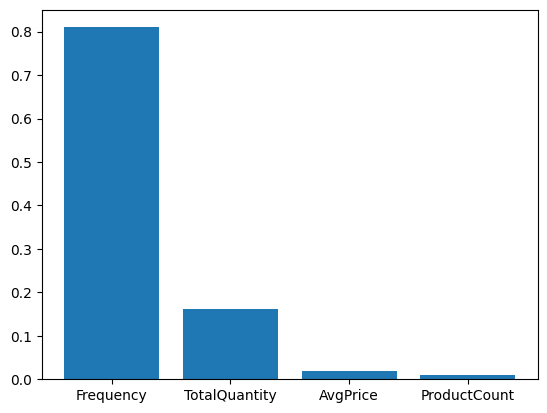

In [98]:
plt.bar(importance['Features'] , importance['Importance'])
plt.show()

In [100]:
from sklearn.model_selection import GridSearchCV
params = {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [2, 3, 5], "subsample": [0.8, 1.0]}

grid = GridSearchCV(XGBRegressor(random_state = 42 , objective = 'reg:squarederror'), params, scoring='r2', cv=5, n_jobs=-1)        #l2 loss(squared loss) ie [(y-y_not)^2]/n
grid.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose

In [101]:
best_model = grid.best_estimator_
best_model.fit(X_train, Y_train)
Y_pred = best_model.predict(X_test)

print(f"r2_score is : {r2_score(Y_test, Y_pred)}")
print(f"MSE is : {mean_squared_error(Y_test, Y_pred)}")
print(f"RMSE is : {(mean_squared_error(Y_test, Y_pred) ** 0.5) }")
print(f"MAE is : {mean_absolute_error(Y_test, Y_pred)}")

r2_score is : 0.6034162728127341
MSE is : 165448331.673396
RMSE is : 12862.67202696998
MAE is : 2592.948116854481


In [102]:
grid.best_params_

{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 300, 'subsample': 1.0}

In [103]:
grid.best_score_

np.float64(0.5027885308199206)

REGRESSION MODEL .... .. ... .. .  . 

In [8]:
from sklearn.model_selection import train_test_split
features = ['Recency','Frequency','Monetary','AverageOrderValue','UniqueProducts','CustomerLifetimeDays']

X = regression_data[features]
Y = regression_data['Future90DaySpend']

X_train , X_test , Y_train ,Y_test = train_test_split(X , Y , train_size = 0.8 , random_state = 42)

print(X_train.shape)
print(X_test.shape)

(2653, 6)
(664, 6)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}

for name, model in models.items():

    model.fit(X_train, Y_train)
    trained_models[name] = model


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for name,model in trained_models.items():
    Y_pred = model.predict(X_test)
    mae = mean_absolute_error(Y_test, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2 = r2_score(Y_test, Y_pred)

    results.append({"Model" : name, "MAE" : mae , "RMSE" : rmse , "R2_SCORE" : r2})

results_df = pd.DataFrame(results).sort_values("MAE")
results_df

,Model,MAE,RMSE,R2_SCORE
3,XGBoost,1553.035216,10159.711126,0.367727
2,Gradient Boosting,1561.136753,9451.437400,0.452811
1,Random Forest,1587.578641,8514.279859,0.555944
0,Linear Regression,1590.698249,8027.506508,0.605267


In [11]:
from sklearn.base import clone

log_trained_models = {}
Y_train_log = np.log1p(Y_train)

for name,model in models.items():
    log_model = clone(model)
    log_model.fit(X_train , Y_train_log)
    log_trained_models[name] = log_model

In [12]:
log_results = []

for name, model in log_trained_models.items():

    Y_pred_log = model.predict(X_test)

    # Convert predictions back to original spending scale
    Y_pred = np.expm1(Y_pred_log)

    # Don't allow negative spending predictions
    Y_pred = np.maximum(Y_pred, 0)

    mae = mean_absolute_error(Y_test, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2 = r2_score(Y_test, Y_pred)

    log_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_SCORE": r2
    })

log_results_df = (
    pd.DataFrame(log_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

log_results_df

,Model,MAE,RMSE,R2_SCORE
0,Random Forest,1415.992555,9224.308304,0.478794
1,Gradient Boosting,1555.274464,11125.979491,0.241740
2,XGBoost,1583.167124,11550.999221,0.182701
3,Linear Regression,2555.428287,20781.416131,-1.645405


In [13]:
def create_temporal_dataset(transactions , cutoff_date , horizon_days = 90):
    cutoff_date = pd.Timestamp(cutoff_date)
    future_end = cutoff_date + pd.Timedelta(days = horizon_days)

    # Historical transactions

    historical = transactions[transactions['InvoiceDate']<cutoff_date].copy()

    cutomer_features = historical.groupby('Customer ID').agg(
        LastPurchaseDate = ('InvoiceDate' , 'max'),
        FirstPurchaseDate = ('InvoiceDate' , 'min'),
        Frequency = ('Invoice' ,'nunique'),
        Monetary = ('Price' ,lambda x: (x * historical.loc[x.index, 'Quantity']).sum()),
        UniqueProducts = ('StockCode' , 'nunique')
    ).reset_index()

    customer_features = cutomer_features.copy()

    customer_features['Recency'] = (cutoff_date - customer_features['LastPurchaseDate']).dt.days
    customer_features['CustomerLifetimeDays'] = (customer_features['LastPurchaseDate'] - customer_features['FirstPurchaseDate']).dt.days + 1
    customer_features['AverageOrderValue'] = (customer_features['Monetary'] - customer_features['Frequency'])
    customer_features['PurchaseRate'] = (customer_features['Frequency'] - customer_features['CustomerLifetimeDays'])
    customer_features = customer_features[customer_features['Customer ID'] > 0].copy()

    # FUTURE 90 days spend

    future = transactions[(transactions['InvoiceDate']>=cutoff_date)&(transactions['InvoiceDate']<future_end).copy()]
    future.loc[: ,'Spend'] = future['Price'] * future['Quantity']

    future_spend = (future.groupby('Customer ID')['Spend'].sum().reset_index().rename(columns= {'Spend': 'Future90DaySpend'}))

    data = customer_features.merge(future_spend,on='Customer ID',how='left')
    data['Future90DaySpend'] = (data['Future90DaySpend'].fillna(0))

    return data

In [14]:
temporal_june = create_temporal_dataset(transactions , '2011-06-01')

print(temporal_june.shape)
temporal_june.head()

(2718, 11)


C:\Users\HP\AppData\Local\Temp\ipykernel_136652\2300889181.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future.loc[: ,'Spend'] = future['Price'] * future['Quantity']


,Customer ID,LastPurchaseDate,FirstPurchaseDate,Frequency,Monetary,UniqueProducts,Recency,CustomerLifetimeDays,AverageOrderValue,PurchaseRate,Future90DaySpend
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,154367.20,1,133,1,154366.20,0,0.00
1,12347,2011-04-07 10:43:00,2010-12-07 14:57:00,3,3646.86,63,54,121,3643.86,-118,1934.86
2,12348,2011-04-05 10:47:00,2010-12-16 19:09:00,3,2974.48,22,56,110,2971.48,-107,0.00
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,668.80,17,118,1,667.80,0,0.00
4,12352,2011-03-22 16:08:00,2011-02-16 12:33:00,5,3123.62,26,70,35,3118.62,-30,0.00


In [15]:
features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AverageOrderValue',
    'UniqueProducts',
    'CustomerLifetimeDays'
]

In [16]:
temporal_june[features + ['Future90DaySpend']].describe()

,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts,CustomerLifetimeDays,Future90DaySpend
count,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000
mean,62.974614,2.725901,2452.238382,2449.512481,41.693157,49.202355,1140.166814
std,52.394210,4.025443,8244.891949,8242.862200,54.396999,60.142270,5479.767052
min,0.000000,1.000000,5.800000,4.800000,1.000000,1.000000,0.000000
25%,19.000000,1.000000,485.435000,484.435000,12.000000,1.000000,0.000000
50%,49.000000,2.000000,952.230000,951.230000,26.000000,1.000000,0.000000
75%,96.000000,3.000000,2140.080000,2135.975000,53.000000,100.000000,942.700000
max,181.000000,86.000000,221426.240000,221401.240000,881.000000,182.000000,131790.240000


In [17]:
print(
    "Negative Recency:",
    (temporal_june['Recency'] < 0).sum()
)

print(
    "Negative Lifetime:",
    (temporal_june['CustomerLifetimeDays'] < 0).sum()
)

print(
    "Negative Future Spend:",
    (temporal_june['Future90DaySpend'] < 0).sum()
)

Negative Recency: 0
Negative Lifetime: 0
Negative Future Spend: 0


In [18]:
cutoffs = ['2011-06-01','2011-07-01','2011-08-01']

temporal_datasets = {}

for date in cutoffs:
    data = create_temporal_dataset(transactions , date , horizon_days = 90)

    temporal_datasets[date] = data

print(
        f"{date} → "
        f"{data.shape[0]} customers | "
        f"Target mean: {data['Future90DaySpend'].mean():.2f} | "
        f"Zero spend: {(data['Future90DaySpend'] == 0).sum()}"
    )

C:\Users\HP\AppData\Local\Temp\ipykernel_136652\2300889181.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future.loc[: ,'Spend'] = future['Price'] * future['Quantity']
C:\Users\HP\AppData\Local\Temp\ipykernel_136652\2300889181.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future.loc[: ,'Spend'] = future['Price'] * future['Quantity']


2011-08-01 → 3148 customers | Target mean: 1329.83 | Zero spend: 1515


C:\Users\HP\AppData\Local\Temp\ipykernel_136652\2300889181.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future.loc[: ,'Spend'] = future['Price'] * future['Quantity']


In [19]:
for date, data in temporal_datasets.items():

    print(f"\n{'='*50}")
    print(f"Cutoff: {date}")
    print(f"Shape: {data.shape}")
    print(f"Date range of target:")
    print(f"  Target > 0: {(data['Future90DaySpend'] > 0).sum()}")
    print(f"  Target = 0: {(data['Future90DaySpend'] == 0).sum()}")


Cutoff: 2011-06-01
Shape: (2718, 11)
Date range of target:
  Target > 0: 1340
  Target = 0: 1378

Cutoff: 2011-07-01
Shape: (2960, 11)
Date range of target:
  Target > 0: 1466
  Target = 0: 1494

Cutoff: 2011-08-01
Shape: (3148, 11)
Date range of target:
  Target > 0: 1633
  Target = 0: 1515


In [20]:
train_data = pd.concat([temporal_datasets['2011-06-01'] , temporal_datasets['2011-07-01']] , ignore_index = True)
validation_data = temporal_datasets['2011-08-01']

features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AverageOrderValue',
    'UniqueProducts',
    'CustomerLifetimeDays'
]

X_train_temporal = train_data[features]             #X_train
Y_train_temporal = train_data['Future90DaySpend']   #Y_train

X_val_temporal = validation_data[features]              #X_test
Y_val_temporal = validation_data['Future90DaySpend']    #Y_test


print("Temporal training:", X_train_temporal.shape)
print("Temporal validation:", X_val_temporal.shape)

Temporal training: (5678, 6)
Temporal validation: (3148, 6)


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_log = RandomForestRegressor(n_estimators = 300 , random_state = 42 , n_jobs = -1)
rf_log.fit(X_train_temporal , np.log1p(Y_train_temporal))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [22]:
Y_val_pred_log = rf_log.predict(X_val_temporal)

Y_val_pred = np.expm1(Y_val_pred_log)
Y_val_pred = np.maximum(Y_val_pred, 0)

mae = mean_absolute_error(Y_val_temporal, Y_val_pred)
rmse = np.sqrt(mean_squared_error(Y_val_temporal, Y_val_pred))
r2 = r2_score(Y_val_temporal, Y_val_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 870.73
RMSE : 3341.03
R²   : 0.7983


In [23]:
rf_raw = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_raw.fit(X_train_temporal, Y_train_temporal)

Y_raw_pred = rf_raw.predict(X_val_temporal)
Y_raw_pred = np.maximum(Y_raw_pred, 0)

print("RAW TARGET")
print(f"MAE  : {mean_absolute_error(Y_val_temporal, Y_raw_pred):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(Y_val_temporal, Y_raw_pred)):.2f}")
print(f"R²   : {r2_score(Y_val_temporal, Y_raw_pred):.4f}")

# as raw data is giving better predictions than log predictions

RAW TARGET
MAE  : 831.46
RMSE : 3306.05
R²   : 0.8025


In [24]:
rf_tuned = RandomForestRegressor(n_estimators = 500 , max_depth = None , min_samples_split = 2 , min_samples_leaf = 2 , max_features = 'sqrt',
                                 random_state = 42 , n_jobs = -1)
rf_tuned.fit(X_train_temporal , Y_train_temporal)

Y_tuned_pred = rf_tuned.predict(X_val_temporal)
Y_tuned_pred = np.maximum(Y_tuned_pred, 0)

print("TUNED RANDOM FOREST")
print(f"MAE  : {mean_absolute_error(Y_val_temporal, Y_tuned_pred):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(Y_val_temporal, Y_tuned_pred)):.2f}")
print(f"R²   : {r2_score(Y_val_temporal, Y_tuned_pred):.4f}")

# still RAW WINS

TUNED RANDOM FOREST
MAE  : 864.07
RMSE : 3479.65
R²   : 0.7812


In [25]:
final_test_data = create_temporal_dataset(
    transactions,
    '2011-09-01'
)

print("Final test shape:", final_test_data.shape)
print(
    "Customers with future spend:",
    (final_test_data['Future90DaySpend'] > 0).sum()
)
print(
    "Customers with zero future spend:",
    (final_test_data['Future90DaySpend'] == 0).sum()
)

Final test shape: (3317, 11)
Customers with future spend: 1864
Customers with zero future spend: 1453


C:\Users\HP\AppData\Local\Temp\ipykernel_136652\2300889181.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future.loc[: ,'Spend'] = future['Price'] * future['Quantity']


In [26]:
final_model = RandomForestRegressor(n_estimators = 300 , random_state = 42 , n_jobs = -1)
final_model.fit(X_train_temporal , Y_train_temporal)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [27]:
X_test_final = final_test_data[features]
Y_test_final = final_test_data['Future90DaySpend']

In [30]:
Y_pred_final = final_model.predict(X_test_final)
Y_pred_final = np.maximum(Y_pred_final,0)

In [ ]:
final_mae = mean_absolute_error(Y_test_final, Y_pred_final)

final_rmse = np.sqrt(mean_squared_error(Y_test_final, Y_pred_final))

final_r2 = r2_score(Y_test_final, Y_pred_final)

print(f"MAE  : {final_mae:.2f}")
print(f"RMSE : {final_rmse:.2f}")
print(f"R²   : {final_r2:.4f}")

MAE  : 1099.13
RMSE : 4432.91
R²   : 0.6801


In [32]:
importance_df = pd.DataFrame({"Feature": features , "Importance":final_model.feature_importances_}).sort_values(by='Importance' , ascending=False)
importance_df

,Feature,Importance
3,AverageOrderValue,0.392207
2,Monetary,0.378713
4,UniqueProducts,0.073749
1,Frequency,0.071621
0,Recency,0.045377
5,CustomerLifetimeDays,0.038333


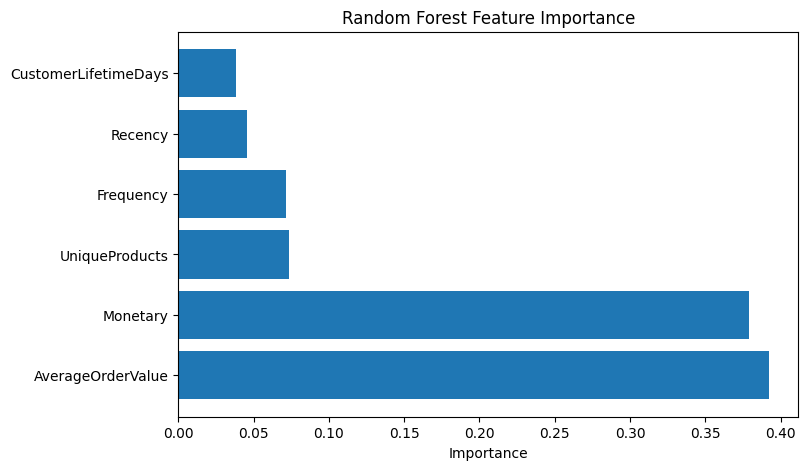

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

In [38]:
production_data = pd.concat([temporal_datasets['2011-06-01'], temporal_datasets['2011-07-01'], temporal_datasets['2011-08-01']], ignore_index=True)

X_production = production_data[features]
Y_production = production_data['Future90DaySpend']

In [39]:
production_model = RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1)

production_model.fit(X_production,Y_production)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [40]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../Model")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(production_model , MODEL_DIR / "future_spend_model.pkl")
joblib.dump(features , MODEL_DIR / "future_spend_features.pkl")

['..\\Model\\future_spend_features.pkl']

In [1]:
print((MODEL_DIR / "future_spend_model.pkl").exists())
print((MODEL_DIR / "future_spend_features.pkl").exists())

NameError: name 'MODEL_DIR' is not defined